## Feature Engineering - Dataset Census Income USA

**¿Qué es Feature Engineering?**

Es el proceso de **transformar datos brutos** en **características/variables numéricas útiles** para modelos de Machine Learning.

**¿Por qué es importante?**
- ✅ Los algoritmos ML necesitan números, no textos
- ✅ Mejora la calidad y precisión de predicciones  
- ✅ Reduce el tiempo de entrenamiento
- ✅ Ayuda a descubrir patrones ocultos

**¿Qué haremos en este notebook?**

1. **Gestión de valores nulos:** Identificar y tratar datos faltantes
2. **Variables categóricas:** Convertir texto en números
3. **Detección de outliers:** Encontrar y manejar valores atípicos
4. **Transformaciones:** Log, discretización, escalado
5. **Pipeline:** Automatizar todo el proceso con un pipeline de scikit-learn
6. **PCA:** Reducir dimensionalidad y visualizar datos

**Dataset:** Census Income KDD (datos de renta USA)
- 200K+ registros de personas
- Variables sociodemográficas
- Target: ingreso ≤/>$50k

#### 0. Importar y Explorar los Datos

**¿Qué haremos?**
1. Descargar dataset de Census Income KDD desde UCI Machine Learning Repository
2. Cargar datos en un DataFrame de pandas
3. Explorar su estructura y contenido
4. Entender qué variables tenemos y sus tipos


Data set tomado de esta url: https://archive.ics.uci.edu/dataset/117/census+income+kdd  
Son datos de renta si es superior o inferior a 50k y como input variables sociodemográficas

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
import numpy as np

| Variable Name |Role|Type   |Demographic|Description|Missing Values |
|---------------|----|-------|-----------|-----------|---------------|
| AAGE | Feature | Integer | Age |age	|	no |
| ACLSWKR|Feature|Categorical||class of worker |	no |
| ADTINK|Feature|Integer||	industry code|		no |
| ADTOCC|	Feature|	Integer|	Occupation|	occupation code	|	no|
| AHGA|	Feature|	Integer|	Education Level|	education|		no|
| AHSCOL|	Feature|	Categorical|	Education Level|	enrolled in edu last week|		no|
| AMARITL|	Feature|	Categorical|	Marital Status|	marital status|		no|
| AMJIND	|Feature|	Categorical||		major industry code	|	no|
| AMJOCC	|Feature|	Categorical|	Occupation|	major occupation code|		no|
| ARACE	|Feature	|Categorical|	Race|	race|		no|
| AREORGN|	Feature|	Categorical|	|	hispanic origin|		no|
| ASEX	|Feature|	Categorical|	Sex|	sex|		no|
| AUNMEM|	Feature|	Categorical|		|member of a labor union|		no|
| AUNTYPE|	Feature|	Categorical|		|reason for unemployment|		no|
| AWKSTAT|	Feature|	Integer|		|full or part time employment stat|		no|
| CAPGAIN|	Feature|	Integer|		|capital gains|		no|
| GAPLOSS|	Feature|	Integer|		|capital losses|		no|
| DIVVAL	|Feature|	Categorical|		|dividends from stocks|		no|
| FILESTAT	|Feature|	Categorical	|	|tax filer status|		no|
| GRINREG	|Feature|	Categorical|		|region of previous residence|		no|
| GRINST	|Feature|	Categorical|		|state of previous residence|		no|
| HHDFMX	|Feature|	Continuous|	Other	|detailed household and family stat|		no|
| HHDREL	|Feature|	Categorical|		|detailed household summary in household|		no|
| MARSUPWRT	|Feature|	Categorical|		|instance weight|		no|
| MIGMTR1	|Feature|	Categorical|		|migration code-change in msa	|	yes|
| MIGMTR3	|Feature|	Categorical|	|migration code-change in reg		|yes|
| MIGMTR4	|Feature|	Categorical|		|migration code-move within reg	|	yes|
| MIGSAME	|Feature|	Integer		| |live in this house 1 year ago		|no|
| MIGSUN	|Feature|	Categorical|		|migration prev res in sunbelt		|yes|
| NOEMP	|Feature|	Categorical	|	|num persons worked for employer		|no|
| PARENT	|Feature|	Categorical|		|family members under 18		|no|
| PEFNTVTY	|Feature|	Categorical	|	|country of birth father		|yes|
| PEMNTVTY	|Feature|	Integer	|	|country of birth mother		|yes|
| PENATVTY	|Feature|	Categorical|	Nationality|	country of birth self		|no|
| PRCITSHP	|Feature|	Integer	|	|citizenship		|no|
| SEOTR	|Feature|	Integer	|	|own business or self employed|		no|
| VETQVA	|Feature|	Categorical		||fill inc questionaire for veteran's admin		|no|
| VETYN	|Feature|	Categorical		||veterans benefits		|no|
| WKSWORK	|Feature|	Categorical		||weeks worked in year|		no|
| income	|Target|	Binary	|Income|	below or above $50k		|no|
| AHRSPAY	|Feature|	Integer		||wage per hour|		no|
| year	|Feature|	Integer		||94 or 95|		no|


In [53]:
# fetch dataset 
census_income_kdd = fetch_ucirepo(id=117) 
df=census_income_kdd.data.original
#df.to_csv("census_income_kdd.csv")

In [54]:
#df = pd.read_csv("census_income_kdd.csv" )
#df.head()

In [55]:
df_or = df

In [56]:
df.head(5)

,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,AMJOCC,...,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,year,income
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,-50000
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,-50000
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,-50000
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,-50000


#### 1. Gestión de Valores Nulos (Missing Values)

**¿Por qué importa?**
- ❌ Los algoritmos ML no pueden trabajar con valores vacíos (NaN)
- ❌ Causan errores en el entrenamiento
- ❌ Distorsionan los resultados si se ignoran

**¿Qué estrategias existen?**

| Estrategia | Cuándo usar | Pros | Contras |
|-----------|-----------|------|---------|
| **Eliminar registros** | Pocos nulos (<5%) | Simple, sin sesgos | Pierdo datos |
| **Eliminar variable completa** | Muchos nulos (>50%) en una columna | Limpia, decisión clara | Pierdo característica |
| **Rellenar con media/mediana** | Valores numéricos | Mantiene tamaño | Puede crear sesgos |
| **Rellenar con moda** | Variables categóricas | Mantiene tamaño | Puede crear sesgos |
| **Imputación avanzada** | Datos importantes | Más preciso | Computacionalmente costoso |

**¿Qué haremos aquí?**
1. Identificar dónde hay valores nulos
2. Probar cada estrategia
3. Ver cómo cambian los datos

#### 1.1 Identificación de omitidos
Creamos una pequeña funcion para identidficar aquellos campos con valores nulos

**¿Qué va a hacer esta función?**

Creamos una función que analiza el dataset y devuelve una tabla limpia con:
- 📋 Nombre de cada columna
- 📊 Cuántos valores no-nulos tiene
- 🔢 Tipo de datos (int, float, object...)
- ⚠️ Porcentaje de valores nulos

Esta tabla nos ayuda a identificar rápidamente qué columnas tienen problemas.

In [57]:
def info_to_dataframe(df):
    # Obtener información básica
    info_dict = {
        'Columna': df.columns.tolist(),
        'No Nulos': df.count().values,
        'Tipo de Dato': df.dtypes.values
    }
    
    # Crear un DataFrame con la información
    info_df = pd.DataFrame(info_dict)
    
    # Calcular el porcentaje de valores nulos
    info_df['Porcentaje Nulos'] = ((df.isnull().sum() / len(df)) * 100).values
    
    return info_df

# Llamar a la función y obtener el DataFrame
info_df = info_to_dataframe(df)

# Mostrar el DataFrame resultante pero solo los campos con nulos
#print(info_df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
21,GRINST,198815,str,0.354846
25,MIGMTR1,99827,str,49.967172
26,MIGMTR3,99827,str,49.967172
27,MIGMTR4,99827,str,49.967172
29,MIGSUN,99827,str,49.967172
32,PEFNTVTY,192810,str,3.364524
33,PEMNTVTY,193404,str,3.066814
34,PENATVTY,196130,str,1.700556


#### Como no hay nulos de variables numericas voy a "estropear" una variable numerica

In [58]:
import random

porcentaje_nulos = 20

num_nulos = int(len(df) * porcentaje_nulos / 100)

# Crear una lista de índices aleatorios
indices_nulos = random.sample(range(len(df)), num_nulos)

# Poner a nulo los valores en los índices aleatorios
df.loc[indices_nulos, 'AHRSPAY'] = None

In [59]:
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
21,GRINST,198815,str,0.354846
25,MIGMTR1,99827,str,49.967172
26,MIGMTR3,99827,str,49.967172
27,MIGMTR4,99827,str,49.967172
29,MIGSUN,99827,str,49.967172
32,PEFNTVTY,192810,str,3.364524
33,PEMNTVTY,193404,str,3.066814
34,PENATVTY,196130,str,1.700556


In [60]:
df.describe()

,AAGE,ADTINK,ADTOCC,AHRSPAY,CAPGAIN,GAPLOSS,DIVVAL,MARSUPWRT,NOEMP,SEOTR,VETYN,WKSWORK,year
count,199523.000000,199523.000000,199523.000000,159619.000000,199523.00000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000,199523.000000
mean,34.494199,15.352320,11.306556,55.190466,434.71899,37.313788,197.529533,1740.380269,1.956180,0.175438,1.514833,23.174897,94.499672
std,22.310895,18.067129,14.454204,273.471872,4697.53128,271.896428,1984.163658,993.768156,2.365126,0.553694,0.851473,24.411488,0.500001
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,37.870000,0.000000,0.000000,0.000000,0.000000,94.000000
25%,15.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1061.615000,0.000000,0.000000,2.000000,0.000000,94.000000
50%,33.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1618.310000,1.000000,0.000000,2.000000,8.000000,94.000000
75%,50.000000,33.000000,26.000000,0.000000,0.00000,0.000000,0.000000,2188.610000,4.000000,0.000000,2.000000,52.000000,95.000000
max,90.000000,51.000000,46.000000,9999.000000,99999.00000,4608.000000,99999.000000,18656.300000,6.000000,2.000000,2.000000,52.000000,95.000000


#### 1.2 Estrategias para tratamiento de nulos
a) quitamos los registros a nulo  
b) quitamos la variable entera  
c) reemplazamos por la media, mediana, ...  

##### a) Eliminamos los registros a nulo

**Ahora probaremos 3 estrategias diferentes para manejar nulos**

Vamos a ver cómo cada estrategia afecta el dataset:
- ¿Cuántos registros se pierden?
- ¿Se resuelven los nulos?
- ¿Cuál es mejor?

In [61]:
df=df_or

In [62]:
df = df.dropna(subset=['GRINST'])
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
5,AHRSPAY,159050,float64,20.001006
25,MIGMTR1,99119,str,50.145110
26,MIGMTR3,99119,str,50.145110
27,MIGMTR4,99119,str,50.145110
29,MIGSUN,99119,str,50.145110
32,PEFNTVTY,192123,str,3.365943
33,PEMNTVTY,192718,str,3.066670
34,PENATVTY,195439,str,1.698061


In [63]:
df.shape[0]

198815

##### b) Quitamos toda la variable

In [64]:
# restauro el data set original
df=df_or

In [65]:
df = df.drop(['MIGMTR1', 'MIGMTR3', 'MIGMTR4'], axis=1)
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
5,AHRSPAY,159619,float64,19.999699
21,GRINST,198815,str,0.354846
26,MIGSUN,99827,str,49.967172
29,PEFNTVTY,192810,str,3.364524
30,PEMNTVTY,193404,str,3.066814
31,PENATVTY,196130,str,1.700556


##### c) Reemplazamos por otro valor

In [66]:
# restauro el data set original
df=df_or

In [67]:
median=df['AHRSPAY'].median()
median

np.float64(0.0)

In [68]:
df['AHRSPAY'].fillna(median, inplace=True)
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

C:\Users\Ciberseguridad & IA\AppData\Local\Temp\ipykernel_14548\1087126908.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['AHRSPAY'].fillna(median, inplace=True)


,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
5,AHRSPAY,159619,float64,19.999699
21,GRINST,198815,str,0.354846
25,MIGMTR1,99827,str,49.967172
26,MIGMTR3,99827,str,49.967172
27,MIGMTR4,99827,str,49.967172
29,MIGSUN,99827,str,49.967172
32,PEFNTVTY,192810,str,3.364524
33,PEMNTVTY,193404,str,3.066814
34,PENATVTY,196130,str,1.700556


In [69]:
# Calcular la moda de la columna
moda = df['MIGSUN'].mode()[0]
moda

' Not in universe'

In [70]:
# Rellenar los valores nulos con la moda
df['MIGSUN'].fillna(moda, inplace=True)
info_df = info_to_dataframe(df)
info_df[info_df['Porcentaje Nulos']>0]

C:\Users\Ciberseguridad & IA\AppData\Local\Temp\ipykernel_14548\2145914407.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['MIGSUN'].fillna(moda, inplace=True)


,Columna,No Nulos,Tipo de Dato,Porcentaje Nulos
5,AHRSPAY,159619,float64,19.999699
21,GRINST,198815,str,0.354846
25,MIGMTR1,99827,str,49.967172
26,MIGMTR3,99827,str,49.967172
27,MIGMTR4,99827,str,49.967172
29,MIGSUN,99827,str,49.967172
32,PEFNTVTY,192810,str,3.364524
33,PEMNTVTY,193404,str,3.066814
34,PENATVTY,196130,str,1.700556


#### ¿Se os ocurre alguna otra estratergia de gestion de nulos?

### 2. Tratamiento de Variables Categóricas

**¿Por qué?** Los algoritmos ML necesitan números. Las variables categóricas (texto) necesitan convertirse a números.

**¿Cuáles son los métodos?**

| Método | Usa | Ventaja | Desventaja |
|--------|-----|---------|-----------|
| **GetDummies** | `pd.get_dummies()` | Rápido, fácil | No funciona en pipelines |
| **OneHotEncoder** | `sklearn` | Funciona en pipelines | Más código |
| **Factorize** | `pd.factorize()` | Simple | Solo ordinal (0,1,2...) |

**Ejemplo:**  
Variable original: `['married', 'single', 'divorced']`

- **GetDummies → 3 columnas:**
  - `married`: [1,0,0]
  - `single`: [0,1,0]  
  - `divorced`: [0,0,1]

**¿Qué haremos?**
1. Usar GetDummies (método simple)
2. Usar OneHotEncoder (método profesional)
3. Ver cómo se estructura el resultado

##### 2.1 Get dummies

In [71]:
FILESTAT = df[['FILESTAT']]
FILESTAT

,FILESTAT
0,Nonfiler
1,Head of household
2,Nonfiler
3,Nonfiler
4,Nonfiler
...,...
199518,Joint both 65+
199519,Joint one under 65 & one 65+
199520,Joint both under 65
199521,Nonfiler


In [72]:
df['FILESTAT'].unique()

<StringArray>
[                    ' Nonfiler',            ' Head of household',
          ' Joint both under 65',                       ' Single',
               ' Joint both 65+', ' Joint one under 65 & one 65+']
Length: 6, dtype: str

In [73]:
df_encoded = pd.get_dummies(df, columns=['FILESTAT'])
df_encoded

,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,AMJOCC,...,VETYN,WKSWORK,year,income,FILESTAT_ Head of household,FILESTAT_ Joint both 65+,FILESTAT_ Joint both under 65,FILESTAT_ Joint one under 65 & one 65+,FILESTAT_ Nonfiler,FILESTAT_ Single
0,73,Not in universe,0,0,High school graduate,0.0,Not in universe,Widowed,Not in universe or children,Not in universe,...,2,0,95,-50000,False,False,False,False,True,False
1,58,Self-employed-not incorporated,4,34,Some college but no degree,NaN,Not in universe,Divorced,Construction,Precision production craft & repair,...,2,52,94,-50000,True,False,False,False,False,False
2,18,Not in universe,0,0,10th grade,0.0,High school,Never married,Not in universe or children,Not in universe,...,2,0,95,-50000,False,False,False,False,True,False
3,9,Not in universe,0,0,Children,0.0,Not in universe,Never married,Not in universe or children,Not in universe,...,0,0,94,-50000,False,False,False,False,True,False
4,10,Not in universe,0,0,Children,NaN,Not in universe,Never married,Not in universe or children,Not in universe,...,0,0,94,-50000,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,NaN,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,2,0,95,-50000,False,True,False,False,False,False
199519,65,Self-employed-incorporated,37,2,11th grade,0.0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,2,52,94,-50000,False,False,False,True,False,False
199520,47,Not in universe,0,0,Some college but no degree,0.0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,2,52,95,-50000,False,False,True,False,False,False
199521,16,Not in universe,0,0,10th grade,0.0,High school,Never married,Not in universe or children,Not in universe,...,2,0,95,-50000,False,False,False,False,True,False


In [74]:
df_encoded.columns

Index(['AAGE', 'ACLSWKR', 'ADTINK', 'ADTOCC', 'AHGA', 'AHRSPAY', 'AHSCOL',
       'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX', 'AUNMEM',
       'AUNTYPE', 'AWKSTAT', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'GRINREG',
       'GRINST', 'HHDFMX', 'HHDREL', 'MARSUPWRT', 'MIGMTR1', 'MIGMTR3',
       'MIGMTR4', 'MIGSAME', 'MIGSUN', 'NOEMP', 'PARENT', 'PEFNTVTY',
       'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'SEOTR', 'VETQVA', 'VETYN',
       'WKSWORK', 'year', 'income', 'FILESTAT_ Head of household',
       'FILESTAT_ Joint both 65+', 'FILESTAT_ Joint both under 65',
       'FILESTAT_ Joint one under 65 & one 65+', 'FILESTAT_ Nonfiler',
       'FILESTAT_ Single'],
      dtype='str')

##### 2.2 One hot encoder

**¿Por qué OneHotEncoder es mejor que GetDummies?**

| Aspecto | GetDummies | OneHotEncoder |
|--------|-----------|---------------|
| 🔧 Integración | No funciona en pipelines | ✅ Funciona en pipelines |
| 📦 Parámetros | Limitados | Muchas opciones |
| 🎯 Profesional | Para exploración | Para producción |
| 💾 Formato | DataFrame | Array |

En esta sección vamos a:
1. Crear el encoder
2. Transformar la variable FILESTAT
3. Ver cómo se crean nuevas columnas binarias
4. Combinar con datos originales

La ventaja de onehotencoder es que se puede incorporar dentro de un pipeline

In [75]:
from sklearn.preprocessing import OneHotEncoder
# Crear un objeto OneHotEncoder
df = df_or
encoder = OneHotEncoder(sparse_output=False)
#El parámetro sparse_output=False asegura que la salida sea un array denso 
#(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.


# Ajustar y transformar los datos
encoded_data = encoder.fit_transform(df[['FILESTAT']])

#FILESTAT_hot = encoder.fit_transform(df[['FILESTAT']])

column_names = encoder.get_feature_names_out(['FILESTAT'])

encoded_df = pd.DataFrame(encoded_data, columns=column_names)

# Concatenar con el DataFrame original 
result = pd.concat([df, encoded_df], axis=1)

print(result)

        AAGE                          ACLSWKR  ADTINK  ADTOCC  \
0         73                  Not in universe       0       0   
1         58   Self-employed-not incorporated       4      34   
2         18                  Not in universe       0       0   
3          9                  Not in universe       0       0   
4         10                  Not in universe       0       0   
...      ...                              ...     ...     ...   
199518    87                  Not in universe       0       0   
199519    65       Self-employed-incorporated      37       2   
199520    47                  Not in universe       0       0   
199521    16                  Not in universe       0       0   
199522    32                          Private      42      30   

                               AHGA  AHRSPAY            AHSCOL  \
0              High school graduate      0.0   Not in universe   
1        Some college but no degree      NaN   Not in universe   
2                    

#### 3. Detección de Outliers (Valores Atípicos)

**¿Qué es un outlier?** Un valor muy diferente al resto. Puede ser:
- ✅ Error de entrada (typo)
- ✅ Error de medición
- ✅ Dato genuino pero raro
- ✅ Fraude

**¿Por qué eliminarlos?**
- ❌ Distorsionan modelos (especialmente regresión)
- ❌ Pueden causar overfitting
- ❌ Afectan métricas de rendimiento

**¿Cómo detectarlos?**

| Método | Fórmula | Sensibilidad | Cuándo usar |
|--------|---------|--------------|-----------|
| **Percentil** | Valor < 5% ó > 95% | Baja | Datos skewed |
| **IQR** | Q1 - 1.5×IQR, Q3 + 1.5×IQR | Media | Distribución normal |
| **Z-Score** | \|x - μ\| / σ > 3 | Alta | Datos muy normales |

**Visualización:**
- 📊 Histograma: ver forma distribución
- 📦 Box Plot: ver outliers visualmente

**¿Qué haremos?**
1. Visualizar con histograma y boxplot
2. Calcular outliers por 3 métodos
3. Eliminar outliers encontrados

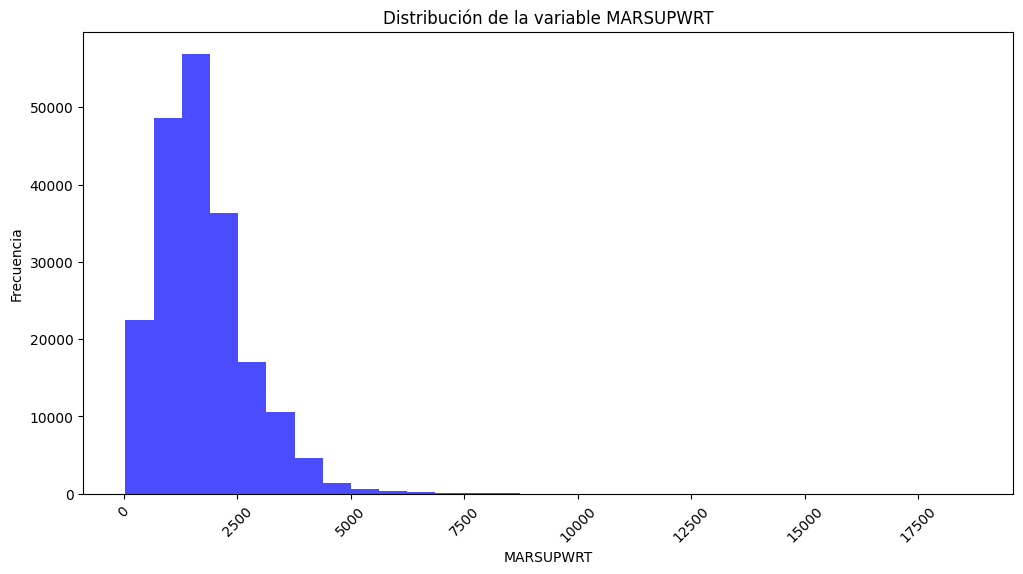

In [76]:
# Graficar la distribución con Seaborn

plt.figure(figsize=(12, 6))
plt.hist(df['MARSUPWRT'], bins=30, color='blue', alpha=0.7)
plt.xlabel('MARSUPWRT')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable MARSUPWRT')
plt.xticks(rotation=45) 
plt.show()

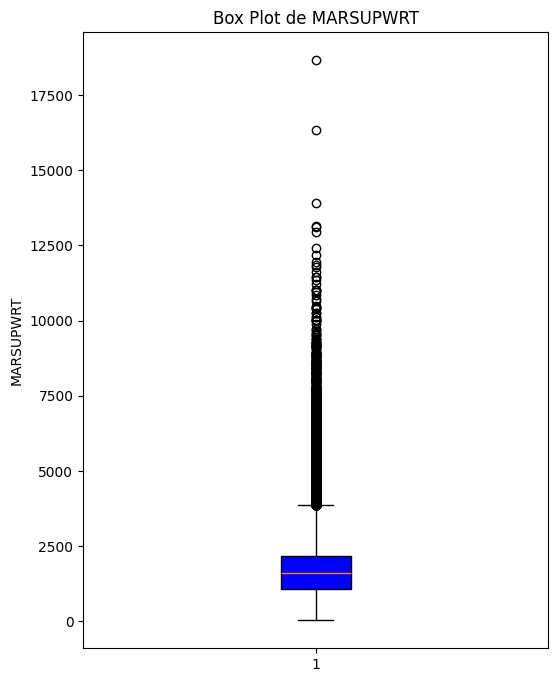

In [77]:
# Crear el box plot vertical
plt.figure(figsize=(6, 8))  # Ajusta el tamaño del gráfico
plt.boxplot(df['MARSUPWRT'], vert=True, patch_artist=True, boxprops=dict(facecolor="blue"))
plt.title('Box Plot de MARSUPWRT')
plt.ylabel('MARSUPWRT')
plt.show()

Forma numérica de identificación de outliers

**Ahora detectaremos outliers de forma numérica**

Vamos a implementar 3 funciones:

1. **percentile_outliers**: Usa percentiles (5% y 95%)
2. **IQR_outliers**: Usa Rango Intercuartil (método estadístico)
3. **zscore_outliers**: Usa puntuaciones Z (desviación estándar)

Cada función devuelve una tabla con los outliers encontrados y sus límites.

In [78]:
def percentile_outliers(df, col:str, var:float = 0.05):
    lower = df[col].quantile(var)
    upper = df[col].quantile(1-var)
    df_percent = df.copy(deep=True)
    df_percent["lower"] = lower
    df_percent["upper"] = upper
    outliers = df_percent[((df_percent[col] < lower) | (df_percent[col] > upper))]
    return outliers[[col, 'lower', 'upper']]

def IQR_outliers(df, col:str):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df_IQR = df.copy(deep=True)
    df_IQR["lower"] = lower
    df_IQR["upper"] = upper
    outliers = df_IQR[((df_IQR[col] < lower) | (df_IQR[col] > upper))]
    return outliers[[col, 'lower', 'upper']]

def zscore_outliers(df, col:str):
    mean = np.mean(df[col])
    std = np.std(df[col])
    df_zscore = df.copy(deep=True)
    df_zscore['z-score'] = (df_zscore[col] - mean) / std
    outliers = df_zscore[abs(df_zscore['z-score']) > 3]
    return outliers[[col, 'z-score']]

In [79]:
df_IQR = IQR_outliers(df, 'MARSUPWRT')
df_IQR
#print("Interquartile range: " + str(df_IQR.index.to_list())) 

,MARSUPWRT,lower,upper
42,4183.26,-628.8775,3879.1025
150,3956.64,-628.8775,3879.1025
157,4450.41,-628.8775,3879.1025
178,4458.53,-628.8775,3879.1025
231,3957.83,-628.8775,3879.1025
...,...,...,...
199367,4438.61,-628.8775,3879.1025
199380,5239.18,-628.8775,3879.1025
199449,7147.13,-628.8775,3879.1025
199459,3901.49,-628.8775,3879.1025


In [80]:
df_per=percentile_outliers(df, 'MARSUPWRT', 0.01)
df_per

,MARSUPWRT,lower,upper
5,162.61,241.2622,4778.2534
47,235.92,241.2622,4778.2534
107,215.84,241.2622,4778.2534
239,5334.50,241.2622,4778.2534
288,7066.72,241.2622,4778.2534
...,...,...,...
199421,238.22,241.2622,4778.2534
199435,232.76,241.2622,4778.2534
199447,192.79,241.2622,4778.2534
199448,230.15,241.2622,4778.2534


In [81]:
zs=zscore_outliers(df, 'MARSUPWRT')
zs

,MARSUPWRT,z-score
239,5334.50,3.616667
288,7066.72,5.359754
318,7104.03,5.397298
523,5175.74,3.456911
772,8209.82,6.510025
...,...,...
199017,5702.65,3.987127
199090,4876.78,3.156076
199315,5886.95,4.172583
199380,5239.18,3.520749


Eliminamos los outliers

In [82]:
outlier_indices = zs.index.tolist()
#outlier_indices
df_filtrado = df.drop(outlier_indices)
df_filtrado

,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,AMJOCC,...,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,year,income
0,73,Not in universe,0,0,High school graduate,0.0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,NaN,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,-50000
2,18,Not in universe,0,0,10th grade,0.0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,-50000
3,9,Not in universe,0,0,Children,0.0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,-50000
4,10,Not in universe,0,0,Children,NaN,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,-50000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,NaN,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Canada,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,-50000
199519,65,Self-employed-incorporated,37,2,11th grade,0.0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,-50000
199520,47,Not in universe,0,0,Some college but no degree,0.0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,Poland,Poland,Germany,Foreign born- U S citizen by naturalization,0,Not in universe,2,52,95,-50000
199521,16,Not in universe,0,0,10th grade,0.0,High school,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,-50000


#### 4. Transformaciones de Variables Continuas

**¿Por qué transformar?**
- 📊 Cambiar distribución para mejor interpretación
- 📊 Mejorar rendimiento de algoritmos
- 📊 Normalizar escalas muy diferentes
- 📊 Reducir el impacto de outliers

**¿Qué transformaciones haremos?**

##### 4.1 Transformación Logarítmica

**¿Para qué?** Convertir distribuciones sesgadas (skewed) en más normales.

**Matemática:**
$$y = \log(x)$$

**Uso:**
- 📈 Ingresos (mayoría baja, algunos muy altos)
- 📈 Valores de empresas
- 📈 Datos que crecen exponencialmente

**Antes vs Después:**
- ❌ Antes: asimétrica, muchos outliers
- ✅ Después: más simétrica, distribución normal

**¿Qué haremos?**
1. Aplicar `log()` a la variable
2. Comparar distribuciones (histograma y boxplot)

In [83]:
df['log_MARSUPWRT'] = np.log(df['MARSUPWRT'])
df['log_MARSUPWRT']

0         7.438436
1         6.959921
2         6.899673
3         7.472012
4         6.974629
            ...   
199518    6.861994
199519    6.532611
199520    7.561657
199521    8.447815
199522    7.512131
Name: log_MARSUPWRT, Length: 199523, dtype: float64

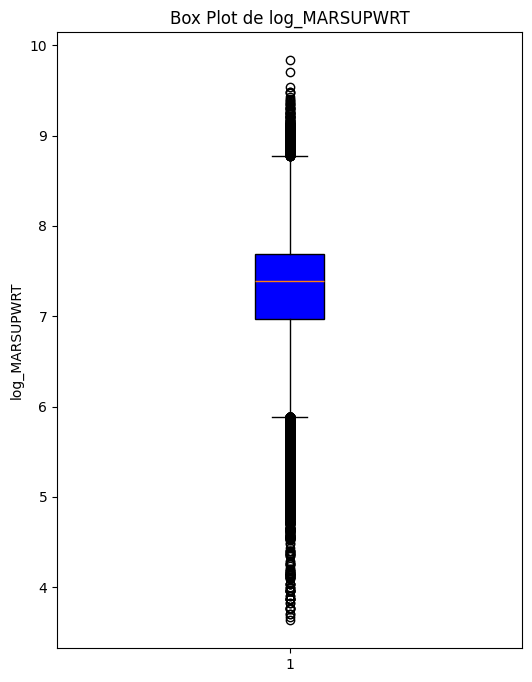

In [84]:
# Crear el box plot vertical
plt.figure(figsize=(6, 8))  # Ajusta el tamaño del gráfico
plt.boxplot(df['log_MARSUPWRT'], vert=True, patch_artist=True, boxprops=dict(facecolor="blue"))
plt.title('Box Plot de log_MARSUPWRT')
plt.ylabel('log_MARSUPWRT')
plt.show()

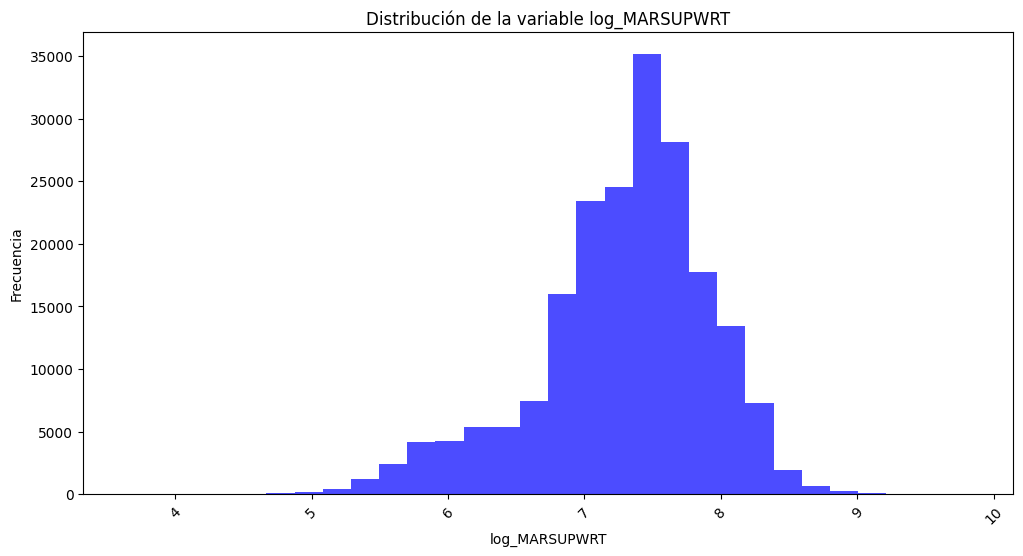

In [85]:
# Graficar la distribución con Seaborn

plt.figure(figsize=(12, 6))
plt.hist(df['log_MARSUPWRT'], bins=30, color='blue', alpha=0.7)
plt.xlabel('log_MARSUPWRT')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable log_MARSUPWRT')
plt.xticks(rotation=45) 
plt.show()

#### 4.2 Discretización (Binning)

**¿Qué es?** Convertir variable **continua** (números decimales) → **categórica** (grupos/bins).

**¿Para qué?**
- 📊 Simplificar variables continuas
- 📊 Capturar relaciones no-lineales
- 📊 Reducir outliers
- 📊 Interpretabilidad (ej: edad en grupos)

**Estrategias:**

| Tipo | Descripción | Uso |
|------|-----------|-----|
| **Uniform** | Bins de igual tamaño | Datos uniformes |
| **Quantile** | Bins con igual frecuencia | Datos desbalanceados |
| **Ordinal** | Ordinal: [0], [1], [2]... | Simple, compacto |
| **Onehot-dense** | 10 columnas × 10 bins | Dense array |
| **Onehot-sparse** | 10 columnas sparse | Ahorra memoria |

**¿Qué haremos?**
1. Discretizar con estrategia **uniform**
2. Discretizar con estrategia **quantile**
3. OneHot encoding densa y sparse

##### Ordinal uniform

In [86]:
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
df['dis_MARSUPWRT']=enc.fit_transform(df[['MARSUPWRT']])
df['dis_MARSUPWRT'].unique()
#df['dis_MARSUPWRT']

array([0., 1., 2., 3., 4., 5., 8., 6., 7., 9.])

**¿Qué va a pasar aquí?**

`KBinsDiscretizer` divide la variable continua en N bins (contenedores).

**Con `strategy='uniform'`:**
- Divide el rango en 10 partes **iguales**
- Independiente de la distribución de datos

**Resultado:**
- Variable original: 0-2000 (continua)
- Discretizada: [1], [2], [3]...[10] (categorías)
- Más fácil de interpretar

In [87]:
enc.fit_transform(df[['MARSUPWRT']])

array([[0.],
       [0.],
       [0.],
       ...,
       [1.],
       [2.],
       [0.]], shape=(199523, 1))

In [88]:
pivot = df.pivot_table(
    values='MARSUPWRT',             # Variable numérica
    index='dis_MARSUPWRT',          # Variable categórica
    aggfunc=['count', 'max', 'min'] # Funciones agregadas: conteo, máximo y mínimo
)

# Renombrar columnas para claridad
pivot.columns = ['Conteo', 'Máximo', 'Mínimo']
pivot.reset_index(inplace=True)

print(pivot)

   dis_MARSUPWRT  Conteo    Máximo    Mínimo
0            0.0  128041   1899.71     37.87
1            1.0   63905   3761.19   1899.74
2            2.0    6678   5620.33   3761.66
3            3.0     683   7477.09   5625.22
4            4.0     167   9290.07   7497.19
5            5.0      33  11025.60   9356.13
6            6.0      11  12960.20  11226.00
7            7.0       3  13911.50  13114.20
8            8.0       1  16349.20  16349.20
9            9.0       1  18656.30  18656.30


##### Ordinal quantile

**¿Cuál es la diferencia con strategy='quantile'?**

Con `strategy='quantile'`:
- Divide en 10 partes con **igual número de elementos** en cada bin
- Si hay 1000 registros → cada bin tiene ~100 registros

**Comparación:**
| Estrategia | Tamaño bins | Distribución |
|-----------|-----------|-------------|
| Uniform | Iguales | Puede desbalanceado |
| Quantile | Diferentes | Siempre balanceado |

**Ventaja:** Mejor para datos muy desbalanceados

In [89]:
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='quantile')
df['dis_MARSUPWRT']=enc.fit_transform(df[['MARSUPWRT']])
df['dis_MARSUPWRT'].unique()
#df['dis_MARSUPWRT']

c:\venvs\ml\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([5., 2., 0., 4., 1., 8., 6., 3., 9., 7.])

In [90]:
pivot = df.pivot_table(
    values='MARSUPWRT',             # Variable numérica
    index='dis_MARSUPWRT',          # Variable categórica
    aggfunc=['count', 'max', 'min'] # Funciones agregadas: conteo, máximo y mínimo
)

# Renombrar columnas para claridad
pivot.columns = ['Conteo', 'Máximo', 'Mínimo']
pivot.reset_index(inplace=True)

print(pivot)

   dis_MARSUPWRT  Conteo    Máximo   Mínimo
0            0.0   19953    596.24    37.87
1            1.0   19952    965.83   596.25
2            2.0   19952   1159.11   965.84
3            3.0   19949   1382.36  1159.14
4            4.0   19953   1618.29  1382.37
5            5.0   19949   1818.78  1618.31
6            6.0   19956   2036.33  1818.81
7            7.0   19954   2397.05  2036.39
8            8.0   19952   3059.71  2397.06
9            9.0   19953  18656.30  3059.85


##### Onehot dense

In [91]:
#KBinsDiscretizer devuelve una matriz de 10 columnas (bins) cada tramos de la discretizacion crea una columna con valor 1 o 0
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=10, encode='onehot-dense', strategy='uniform')
valores_discretizados = enc.fit_transform(df[['MARSUPWRT']])
valores_discretizados

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(199523, 10))

**¿Qué diferencia hay entre `ordinal`, `onehot-dense` y `onehot`?**

Tenemos 10 bins, variable original puede tomar 10 valores diferentes:

| encode | Resultado | Ejemplo |
|--------|-----------|---------|
| `ordinal` | 1 columna | [5] (el valor 5) |
| `onehot-dense` | 10 columnas array denso | [0,0,0,0,0,1,0,0,0,0] |
| `onehot` | 10 columnas array **sparse** | matriz comprimida (ahorra RAM) |

**¿Cuándo usar cada uno?**
- `ordinal`: Pocos bins, quiero compacto
- `onehot-dense`: Algoritmos que necesitan todas las columnas
- `onehot`: Muchas columnas, limitación de RAM

In [92]:
# Convertir la salida en un DataFrame y unir con el original
df_discretizado = pd.DataFrame(valores_discretizados, columns=[f'Bin_{i}' for i in range(valores_discretizados.shape[1])])
# Mostrar el DataFrame final
#print(df_final)
df_final = df.join(df_discretizado)
df_final

,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHRSPAY,AHSCOL,AMARITL,AMJIND,AMJOCC,...,Bin_0,Bin_1,Bin_2,Bin_3,Bin_4,Bin_5,Bin_6,Bin_7,Bin_8,Bin_9
0,73,Not in universe,0,0,High school graduate,0.0,Not in universe,Widowed,Not in universe or children,Not in universe,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,58,Self-employed-not incorporated,4,34,Some college but no degree,NaN,Not in universe,Divorced,Construction,Precision production craft & repair,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,18,Not in universe,0,0,10th grade,0.0,High school,Never married,Not in universe or children,Not in universe,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,9,Not in universe,0,0,Children,0.0,Not in universe,Never married,Not in universe or children,Not in universe,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10,Not in universe,0,0,Children,NaN,Not in universe,Never married,Not in universe or children,Not in universe,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199518,87,Not in universe,0,0,7th and 8th grade,NaN,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
199519,65,Self-employed-incorporated,37,2,11th grade,0.0,Not in universe,Married-civilian spouse present,Business and repair services,Executive admin and managerial,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
199520,47,Not in universe,0,0,Some college but no degree,0.0,Not in universe,Married-civilian spouse present,Not in universe or children,Not in universe,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
199521,16,Not in universe,0,0,10th grade,0.0,High school,Never married,Not in universe or children,Not in universe,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Onehot

In [93]:
enc = KBinsDiscretizer(n_bins=3, encode='onehot', strategy='uniform')

# Aplicar la transformación
valores_discretizados = enc.fit_transform(df[['MARSUPWRT']])

# Convertir la matriz dispersa a un DataFrame y unirla con el original
df_discretizado = pd.DataFrame(valores_discretizados.toarray(), columns=[f'Bin_{i}' for i in range(valores_discretizados.shape[1])])
df_final = df.join(df_discretizado)

# Mostrar el DataFrame final con la discretización
print(df_final)

        AAGE                          ACLSWKR  ADTINK  ADTOCC  \
0         73                  Not in universe       0       0   
1         58   Self-employed-not incorporated       4      34   
2         18                  Not in universe       0       0   
3          9                  Not in universe       0       0   
4         10                  Not in universe       0       0   
...      ...                              ...     ...     ...   
199518    87                  Not in universe       0       0   
199519    65       Self-employed-incorporated      37       2   
199520    47                  Not in universe       0       0   
199521    16                  Not in universe       0       0   
199522    32                          Private      42      30   

                               AHGA  AHRSPAY            AHSCOL  \
0              High school graduate      0.0   Not in universe   
1        Some college but no degree      NaN   Not in universe   
2                    

##### 4.3 Escalado (Scaling)

**¿Por qué escalar?**

Algunos algoritmos usan distancias:
- 🔴 **KNN, KMeans, SVM, Regresi ón** → NECESITAN escalado
- 🟢 **Árboles, Random Forest** → NO lo necesitan

**Problema:**
- Variable A: rango 0-100
- Variable B: rango 1M-2M
- ⚠️ B domina solo por escala, no importancia

**¿Qué escaladores existen?**

| Escalador | Fórmula | Rango | Uso |
|-----------|---------|-------|-----|
| **MinMaxScaler** | (x-min)/(max-min) | [0, 1] | Datos con outliers |
| **StandardScaler** | (x-μ)/σ | [-∞, ∞] | Distribución normal |

**Diferencia visual:**
- MinMax: todos valores entre 0-1
- StandardScaler: media=0, std=1, algunos negativos

**¿Qué haremos?**
1. Aplicar **MinMaxScaler** → valores [0,1]
2. Aplicar **StandardScaler** → distribución normal
3. Comparar histogramas y estadísticas

In [94]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
min_max_scaler = MinMaxScaler()
df['minmax_MARSUPWRT'] = min_max_scaler.fit_transform(df[['MARSUPWRT']])
df['minmax_MARSUPWRT']

0         0.089278
1         0.054552
2         0.051244
3         0.092396
4         0.055391
            ...   
199518    0.049274
199519    0.034875
199520    0.101252
199521    0.248517
199522    0.096262
Name: minmax_MARSUPWRT, Length: 199523, dtype: float64

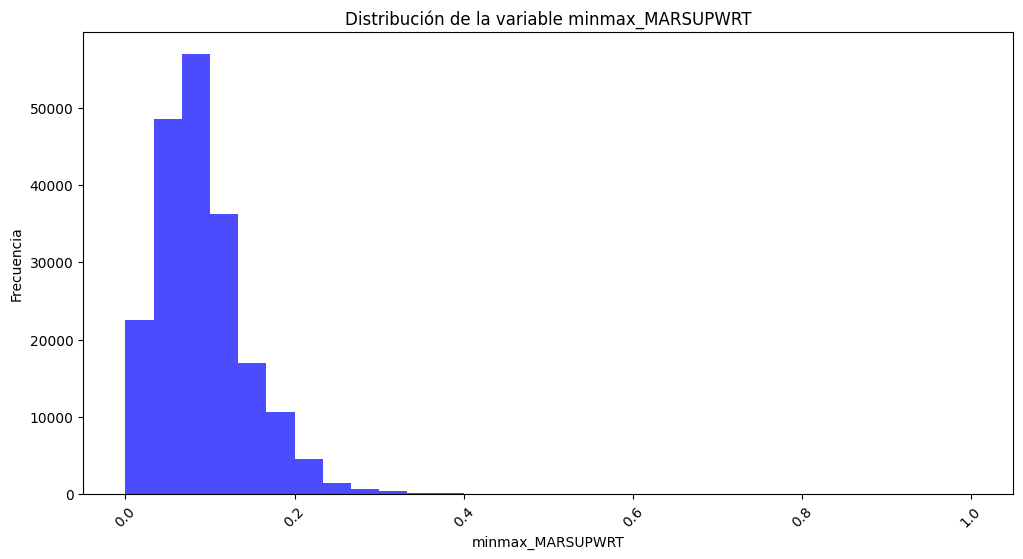

In [95]:

plt.figure(figsize=(12, 6))
plt.hist(df['minmax_MARSUPWRT'], bins=30, color='blue', alpha=0.7)
plt.xlabel('minmax_MARSUPWRT')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable minmax_MARSUPWRT')
plt.xticks(rotation=45) 
plt.show()

In [96]:
media = df['minmax_MARSUPWRT'].mean()
desviacion = df['minmax_MARSUPWRT'].std()
print(media, desviacion)

0.09144220373534515 0.053375507805298636


In [97]:

std_scaler = StandardScaler()
df['std_MARSUPWRT'] = std_scaler.fit_transform(df[['MARSUPWRT']])
df['std_MARSUPWRT']

0        -0.040543
1        -0.691139
2        -0.753126
3         0.017871
4        -0.675431
            ...   
199518   -0.790036
199519   -1.059797
199520    0.183796
199521    2.942836
199522    0.090293
Name: std_MARSUPWRT, Length: 199523, dtype: float64

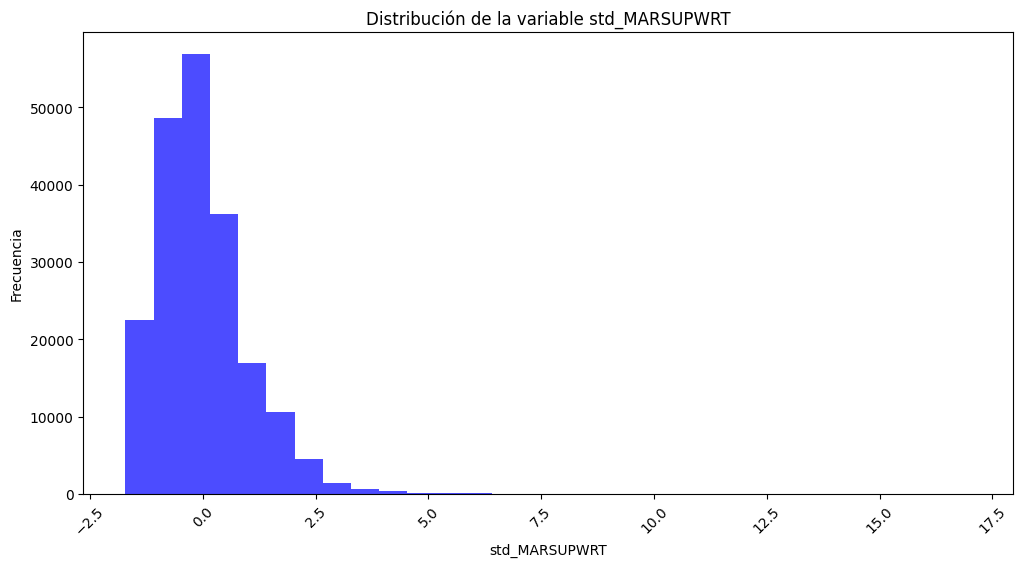

In [98]:
plt.figure(figsize=(12, 6))
plt.hist(df['std_MARSUPWRT'], bins=30, color='blue', alpha=0.7)
plt.xlabel('std_MARSUPWRT')
plt.ylabel('Frecuencia')
plt.title('Distribución de la variable std_MARSUPWRT')
plt.xticks(rotation=45) 
plt.show()

In [99]:
media = df['std_MARSUPWRT'].mean()
desviacion = df['std_MARSUPWRT'].std()
print(media, desviacion)

-2.1196305003654296e-16 1.0000025059861746


#### 5. Pipeline: Automatizar Todo el Feature Engineering

**¿Qué es un Pipeline?** Una **cadena automática** de transformaciones.

**¿Por qué es útil?**

❌ **Sin Pipeline (manual):**
```
Data → Encoding → Quitar Nulos → Escalar → Modelo
       (paso 1)     (paso 2)     (paso 3)   (paso 4)
```
- Fácil olvidar un paso
- Código desorganizado
- Difícil reproducible

✅ **Con Pipeline (automático):**
```
fit_transform() → todos los pasos en orden
```
- Código limpio y organizado
- Reproducible
- Fácil de mantener

**¿Qué pasos haremos?**

| Paso | Función | Entrada | Salida |
|------|---------|---------|--------|
| 1️⃣ | OneHotEncoding | Variables categóricas | Todo numérico |
| 2️⃣ | Quitar nulos | Registros con NaN | Dataset limpio |
| 3️⃣ | Escalar | Valores sin escala | Valores [0,1] |
| 4️⃣ | PCA | Muchas columnas | 2 componentes |
| 5️⃣ | DataFrame | Array | DataFrame |

**Resultado:**
- 📊 Datos transformados y listos para ML
- 📊 Gráfico PCA 2D para visualizar

In [100]:
from sklearn.preprocessing import FunctionTransformer, normalize, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

**Ahora definiremos funciones reutilizables para el pipeline**

Cada función hará **una transformación específica**:

1. `tipo_variables()`: Identifica qué columnas son numéricas y cuáles categóricas
2. `MyHotEncoder()`: Codifica todas las variables categóricas
3. `quitar_nulos()`: Elimina registros con NaN
4. `normalizar()`: Normaliza valores (0 a 1)
5. `escalar()`: Escala con StandardScaler
6. `to_df()`: Convierte array a DataFrame

Luego las encadenaremos en un Pipeline automático.

In [101]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols

In [102]:
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

['ACLSWKR', 'AHGA', 'AHSCOL', 'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX', 'AUNMEM', 'AUNTYPE', 'AWKSTAT', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN', 'PARENT', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'VETQVA', 'income']
['AAGE', 'ADTINK', 'ADTOCC', 'AHRSPAY', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'MARSUPWRT', 'NOEMP', 'SEOTR', 'VETYN', 'WKSWORK', 'year', 'log_MARSUPWRT', 'dis_MARSUPWRT', 'minmax_MARSUPWRT', 'std_MARSUPWRT']


In [103]:
def MyHotEncoder(X):
    from sklearn.preprocessing import OneHotEncoder
    # Crear un objeto OneHotEncoder
    encoder = OneHotEncoder(sparse_output=False)
    cat_vbles = tipo_variables(X)[1]
    #El parámetro sparse_output=False asegura que la salida sea un array denso 
    #(en lugar de una matriz dispersa), lo cual es más fácil de convertir en un DataFrame de pandas.
    for i in cat_vbles:
        encoded_data = encoder.fit_transform(X[[i]])
        column_names = encoder.get_feature_names_out([i])
        encoded_X=pd.DataFrame(encoded_data, columns=column_names)
        X = pd.concat([X, encoded_X], axis=1)
    X = X.drop(columns=cat_vbles)
    return X

In [104]:
def quitar_nulos(df):
    df_sin_nulos = df.dropna()
    return df_sin_nulos

In [105]:
def normalizar(df):
    df_norm= preprocessing.normalize(df)
    return df_norm

In [106]:
def escalar(df):
    scaler = StandardScaler()
    df_scaled= scaler.fit_transform(df)
    df_scaled=pd.DataFrame(df_scaled, columns=df.columns)
    return df_scaled

In [107]:
def to_df(array):
    df_pca=pd.DataFrame(array, columns=['pca1', 'pca2'])
    return df_pca

In [108]:
pipeline = Pipeline([
    ('MyHotEncoder', FunctionTransformer(MyHotEncoder)),  # Paso 1: grestina variables c4tePCA
    ('quitar_nulos', FunctionTransformer(quitar_nulos)),  # Paso 2: quita registros con nulos
    ('escalar', FunctionTransformer(escalar))   ,         # Paso 3: escalar
    ('pca', PCA(n_components=2))  ,                       # Paso 4: PCA
    ('pasar a dataframe',FunctionTransformer(to_df))      # Paso5: PAsar a DataFrame
])    

**Ahora construimos el PIPELINE: la cadena automática**

El pipeline define el flujo de transformaciones en orden:

```
Data bruto
    ↓
[1] MyHotEncoder → todo numérico
    ↓
[2] quitar_nulos → sin NaN
    ↓
[3] escalar → valores normalizados
    ↓
[4] PCA → reducir a 2 componentes
    ↓
[5] to_df → convertir a DataFrame
    ↓
Data transformado listo para visualizar/ML
```

**Ventajas:**
- ✅ Una sola línea: `pipeline.fit_transform(df)`
- ✅ Reproducible: mismo orden siempre
- ✅ Automático: no hay que hacer nada manual

In [109]:
X_pca = pipeline.fit_transform(df)
X_pca


,pca1,pca2
0,1.182873,3.943565
1,1.957552,4.376043
2,5.992959,-2.185082
3,-2.911976,-3.755208
4,-2.793281,-3.750908
...,...,...
159614,-0.189636,3.714909
159615,-2.071458,-3.547819
159616,-1.629152,2.698711
159617,3.927769,4.302208


In [110]:
# Extraer componentes
componente_1 = X_pca['pca1']
componente_2 = X_pca['pca2']

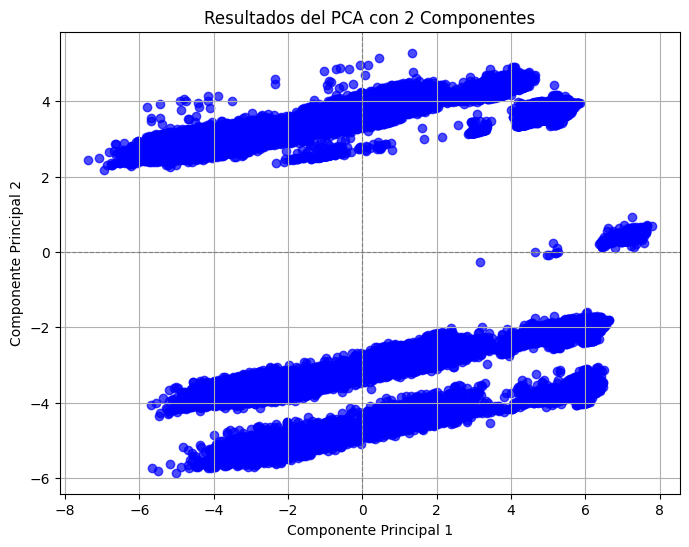

In [111]:
# Graficar los resultados del PCA
plt.figure(figsize=(8, 6))
plt.scatter(componente_1, componente_2, c='blue', alpha=0.7)
plt.title('Resultados del PCA con 2 Componentes')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.grid(True)
plt.show()

---

## Resumen Completo: Feature Engineering de Principio a Fin

### ¿Qué hemos hecho?

| Fase | Técnica | Objetivo | Resultado |
|------|---------|----------|-----------|
| 1️⃣ **Limpieza** | Gestión de nulos | Datos sin vacíos | Dataset completo |
| 2️⃣ **Encoding** | OneHotEncoder | Texto → Números | Todo numérico |
| 3️⃣ **Detección** | IQR, Z-score, Percentil | Encontrar anomalías | Outliers identificados |
| 4️⃣ **Transformación** | Log, Discretización | Mejorar distribuciones | Datos más normales |
| 5️⃣ **Escalado** | MinMax, StandardScaler | Normalizar rangos | Valores comparables |
| 6️⃣ **Automatización** | Pipeline | Encadenar todo | Proceso reproducible |
| 7️⃣ **Reducción** | PCA | De miles a 2 dimensiones | Visualización 2D |

### Pipeline Paso a Paso:

```
Dataset Crudo (200K × 42 variables)
        ↓
[1] OneHotEncoder → Variables categóricas a binarias
        ↓
[2] Quitar Nulos → Registros sin NaN
        ↓
[3] StandardScaler → Media=0, Desv.Est=1
        ↓
[4] PCA(n_components=2) → Reducción dimensionalidad
        ↓
Datos Transformados (200K × 2 componentes)
        ↓
📊 Gráfico 2D para visualizar
```

### ¿Por qué todo esto?

✅ **Antes:** Dataset con problemas (nulos, escalas diferentes, categorías texto)  
❌ **Problema:** Algoritmo ML no entiende nada  
✅ **Después:** Datos numéricos, escalados, limpios  
✅ **Resultado:** Algoritmo ML puede entrenar correctamente

### ¿Qué sigue?

Con estos datos transformados podemos:
- 🎯 Entrenar modelos de clasificación (predecir ingresos)
- 🤖 Hacer clustering (agrupar personas similares)
- 📈 Análisis exploratorio con confianza
- 🔍 Seleccionar features más importantes

### Recuerda:

> "Feature Engineering es 80% del trabajo de un Data Scientist. El 20% restante es elegir el modelo."

Un buen Feature Engineering → Modelo simple funciona bien  
Mal Feature Engineering → Modelo complejo sigue fallando

**Visualizar los datos transformados con PCA**

El PCA ha reducido todas las características originales a solo 2 componentes.

**¿Qué vamos a ver?**
- 📊 Scatter plot con miles de puntos
- 📍 Cada punto = una persona del dataset
- 🎨 Cada región del gráfico = grupo de personas similares

**Interpretación:**
- ✅ Si hay clusters claros → buena segmentación
- ✅ Si están esparcidos → características muy variables
- ✅ Puntos aislados → posibles outliers o casos especiales

**¿Por qué es importante?**
- Verifica que nuestras transformaciones funcionan
- Visualiza datos con muchas dimensiones en 2D
- Detecta problemas antes de entrenar modelo ML